In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
from scipy import stats
import scanpy as sc
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
import anndata

intersted_genes = ['Gpr101','Pdyn','Trhr','Tacr3','Shox2']
markergenes = ['Dbh', 'Th', 'Slc6a2']
import sys 
sys.path.append('/home/shuonan.chen/scratch_shuonan/code/LCNE_transcriptomics/code/')
import plotting,utils
allmeshes = utils.load_mesh()

# load data

In [2]:
adata_foo = sc.read_h5ad("/home/shuonan.chen/scratch_shuonan//LC_scRNAseq/conversion_files/snRNAseq_LCNE_BN_new.h5ad")
adata_sc = anndata.AnnData(adata_foo.layers['BN'])
adata_sc.obs = adata_foo.obs.copy()
adata_sc.obsm = adata_foo.obsm.copy()
adata_sc.var = adata_foo.var.copy()

filename = '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/data/adata_mer_subset_2_6k.h5ad'
adata_mer = sc.read_h5ad(filename)
var_names = adata_mer.var_names.intersection(adata_sc.var_names)
adata_mer = adata_mer[:,var_names]  # 314 genes 

In [3]:
adata_sc.shape, adata_mer.shape

((4895, 5126), (2651, 314))

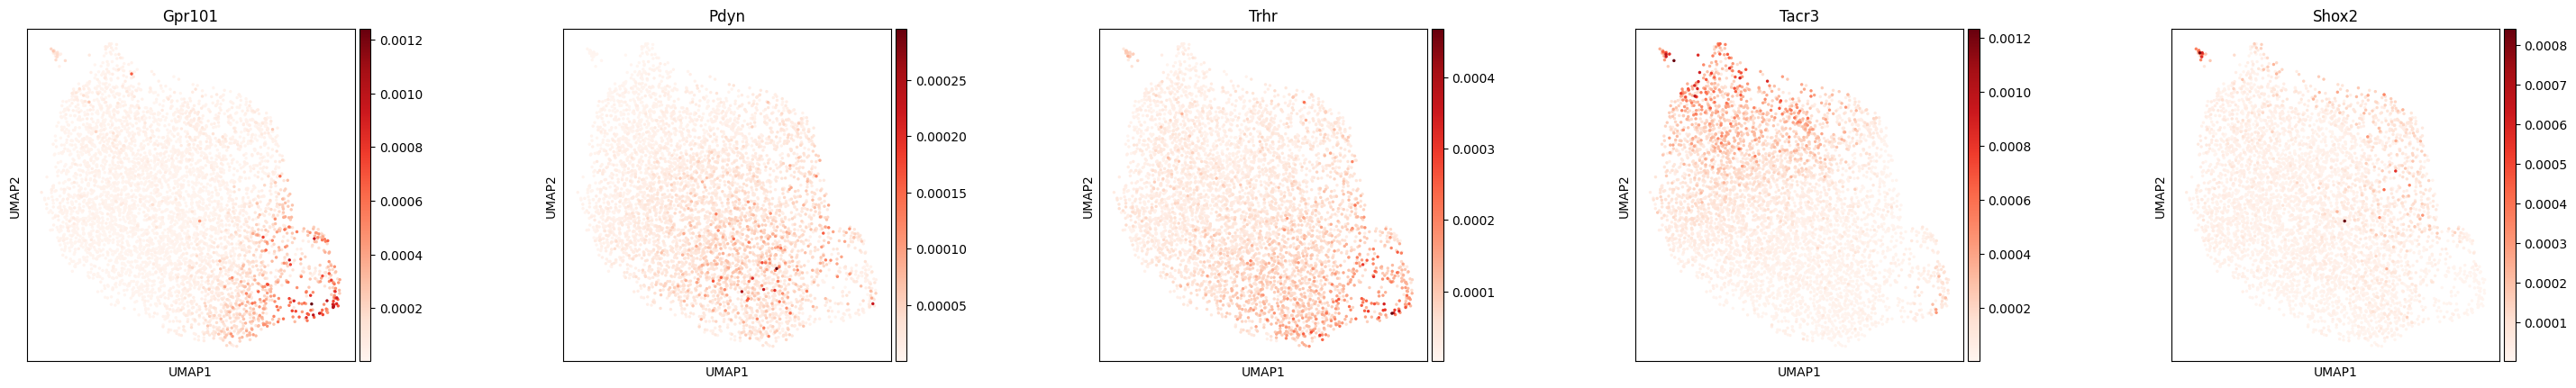

In [4]:
ax = sc.pl.umap(adata_sc,color=intersted_genes,ncols=5,show = False, cmap = 'Reds')
for a in ax:
    a.set_aspect('equal')

# load merfish 

/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12040. The TBB threading layer is disabled.
  warnings.warn(problem)


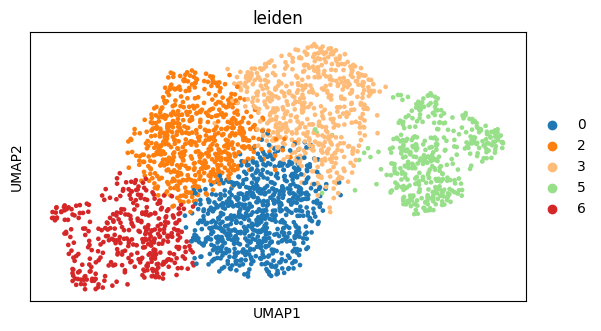

In [5]:
umap_random_state = 307
sc.pp.neighbors(adata_mer, use_rep="X_scVI",  random_state=umap_random_state)
sc.tl.umap(adata_mer, random_state=210)

a = sc.pl.umap(adata_mer, color='leiden', show = False)
a.set_aspect('equal')

In [6]:
adata_mer.shape

(2651, 314)

# impute!
arc_info is saved from this notebook `all_figs_snRNA_modularized`!
(04/16)

In [7]:
import sys
sys.path.append('/home/shuonan.chen/scratch_shuonan/code/LCNE_transcriptomics/code/')
from imputations import *

In [8]:
import pickle 
arc_info = pickle.load(open('/home/shuonan.chen/scratch_shuonan/LC_scRNAseq/arc_info_2d.pkl', 'rb'))
locals().update(arc_info)

inverse_order = np.argsort(allcells_new_order)
t_projections_original_order = t_projections[inverse_order]


In [9]:
adata_sc.shape, adata_mer.shape

((4895, 5126), (2651, 314))

In [10]:
union_genes = np.union1d(adata_sc.var_names, adata_mer.var_names)  # > n_hvg
union_genes.shape

(5126,)

In [11]:
common_genes = np.intersect1d(adata_mer.var_names, adata_sc.var_names)
print(common_genes.shape)
adata_sc_ref = adata_sc[:, common_genes].copy()  # we will impute based on this guy, number of `union_genes=2184` will be imputed. 


(314,)


In [12]:
k = 10
X_sc = adata_sc_ref[:, common_genes].X
X_mer = adata_mer[:, common_genes].X     
X_sc_norm = normalize_cols(X_sc, ranked=True)
X_mer_norm = normalize_cols(X_mer, ranked=True)
nbrs = NearestNeighbors(n_neighbors=k, metric='euclidean').fit(X_sc_norm)
distances, indices = nbrs.kneighbors(X_mer_norm) # distance: size (N_mer, K)
epsilon = 1e-10
weights = 1 / (distances + epsilon)
weights = weights / weights.sum(axis=1, keepdims=True)  # normalize so that weights sum to 1

In [13]:
imputed_t_loc = np.zeros((adata_mer.n_obs))
for i in range(adata_mer.n_obs):
    neighbor_idx = indices[i]    
    imputed_t_loc[i] = np.dot(weights[i], t_projections_original_order[neighbor_idx])

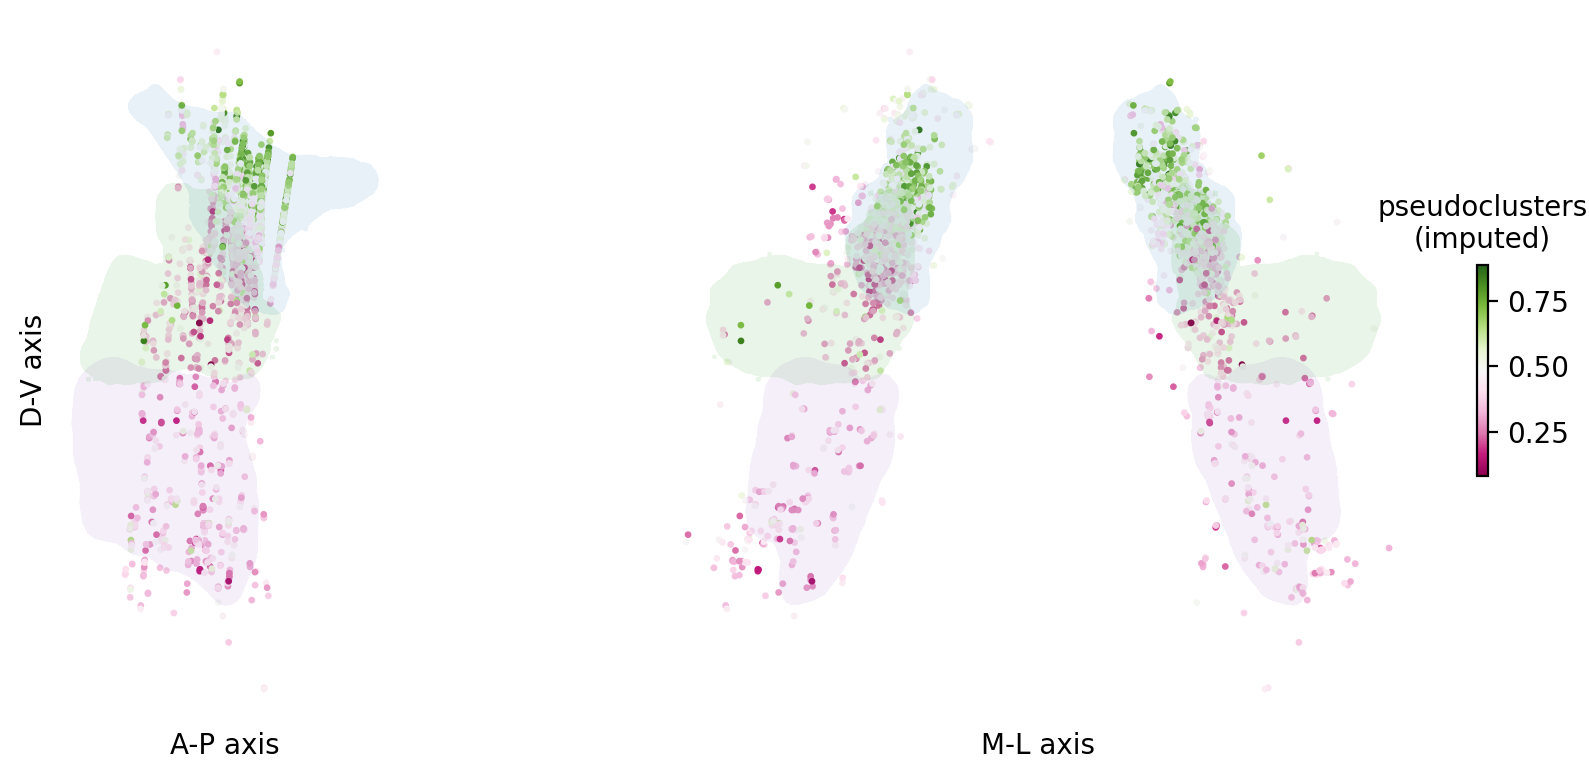

In [25]:
s = 2
plt.figure(figsize = (10, 4))
plt.subplot(1,2,1)
sca = plt.scatter(adata_mer.obsm['spatial'][:,0],adata_mer.obsm['spatial'][:,1],
                  cmap ='PiYG',s =s,
                  c =imputed_t_loc)    
plotting.plot_mesh(plt.gca(), allmeshes,direction = 's')
plt.ylabel("D-V axis");
plt.xlabel("A-P axis") 
plt.xticks([]);plt.gca().set_yticks([]);
for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.subplot(1,2,2)
sca = plt.scatter(adata_mer.obsm['spatial'][:,2],adata_mer.obsm['spatial'][:,1],
                  cmap ='PiYG',s =s,
                  c =imputed_t_loc) 
cbar = plt.colorbar(sca, ax=plt.gca(),  shrink=0.3)
cbar.ax.xaxis.set_label_position('top')
cbar.ax.set_xlabel(f"pseudoclusters\n(imputed)", ha='center', va='bottom')
plotting.plot_mesh(plt.gca(), allmeshes,direction = 'c')
plt.xlabel("M-L axis") 
plt.xticks([]);plt.yticks([]);
for spine in plt.gca().spines.values():
    spine.set_visible(False)

    
plt.tight_layout()
plt.gcf().set_dpi(200)  # set dpi for the entire figure
    
    


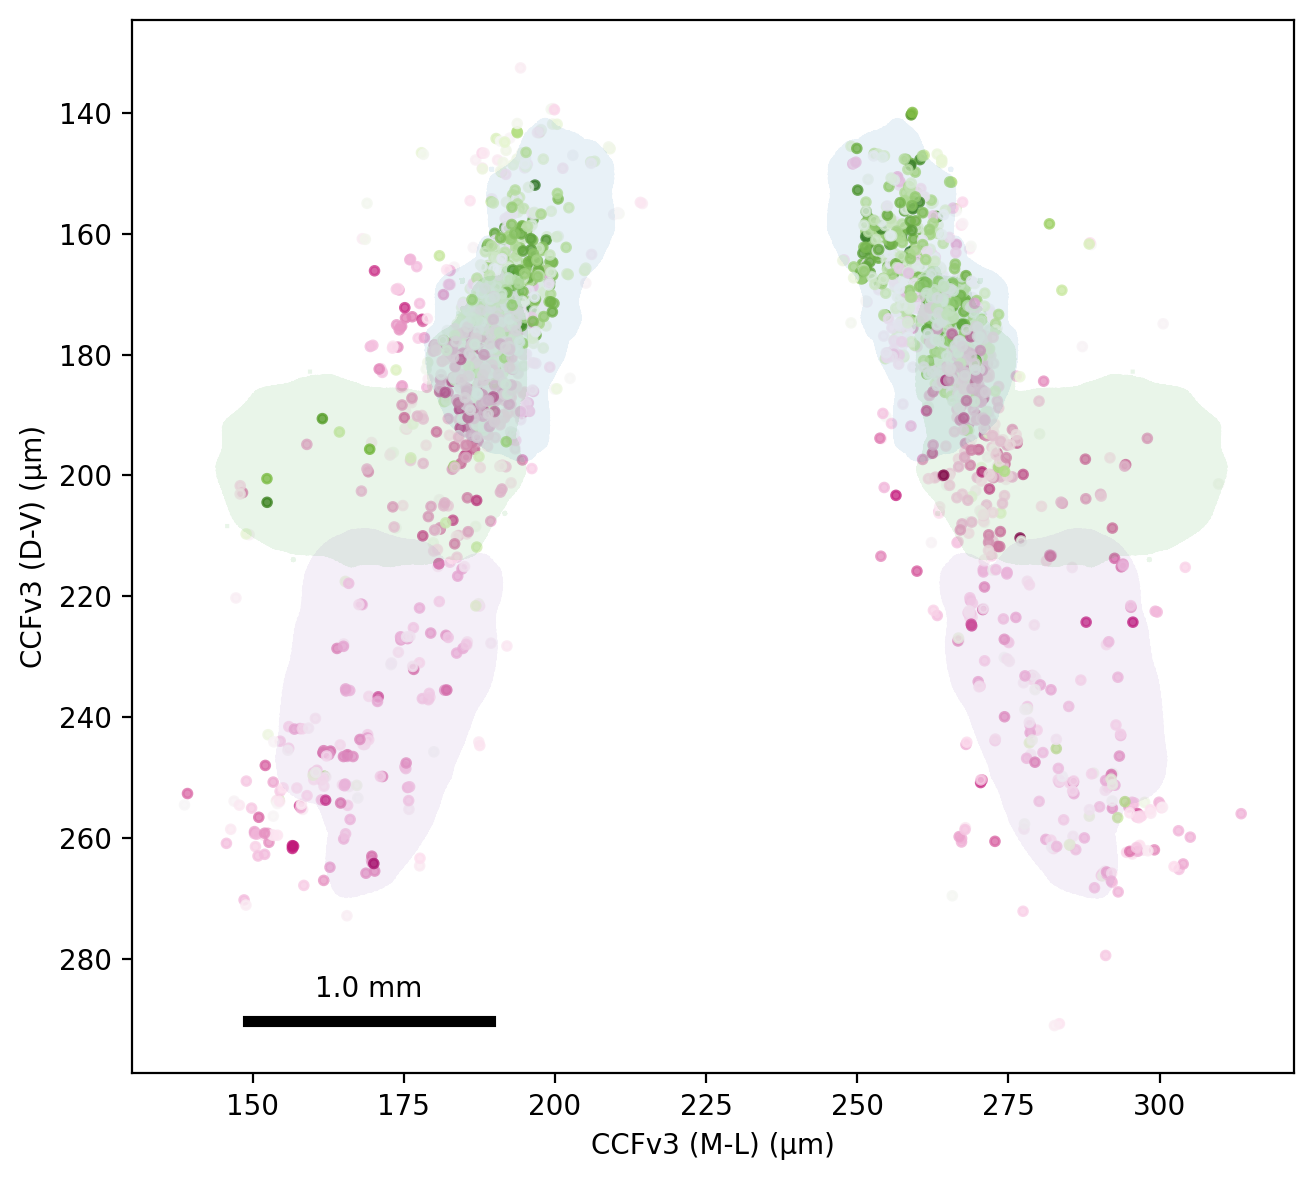

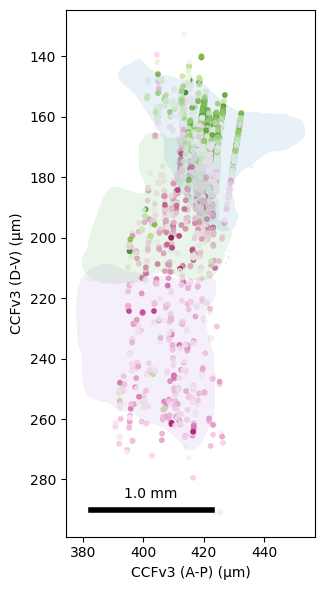

In [37]:
   
s = 10
meshes = load_mesh()
fig, ax = plt.subplots(figsize=(9,6))
plot_spatial(ax,
             adata=adata_mer,
             coords=adata_mer.obsm['spatial'],
             colorvalues=imputed_t_loc,
             meshes=meshes,cmap = 'PiYG',
             dims=(2,1),
             xlabel='CCFv3 (M-L) (μm)',
             ylabel='CCFv3 (D-V) (μm)',
             s=s,
             colorbartitle = 'estimated locations on the curve'
            )
plt.tight_layout()
plt.gcf().set_dpi(200)


fig, ax = plt.subplots(figsize=(9,6))
plot_spatial(ax,
             adata=adata_mer,
             coords=adata_mer.obsm['spatial'],
             colorvalues=imputed_t_loc,
             meshes=meshes,cmap = 'PiYG',
             dims=(0,1),
             xlabel='CCFv3 (A-P) (μm)',
             ylabel='CCFv3 (D-V) (μm)',
             s=s,)
plt.tight_layout()